# EDA, Data Cleaning, Feature Engineering & Selection


In [2]:
# Imports & load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

sns.set(style='whitegrid')
df = sns.load_dataset('titanic')
df_original = df.copy()
print('Dataset loaded. Shape:', df.shape)
df.head()

Dataset loaded. Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1) Exploratory Data Analysis (EDA)

- Quick look: shape, dtypes, head
- Summary statistics and missing value overview
- Visualizations: distributions and categorical counts


In [21]:
# Basic info and summary
print('Shape:', df.shape)
display(df.info())
display(df.describe(include='all').T)

# Missing values overview
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
pd.concat([missing.rename('number'), missing_pct.rename('pct')], axis=1).head(20)

Shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,number,pct
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


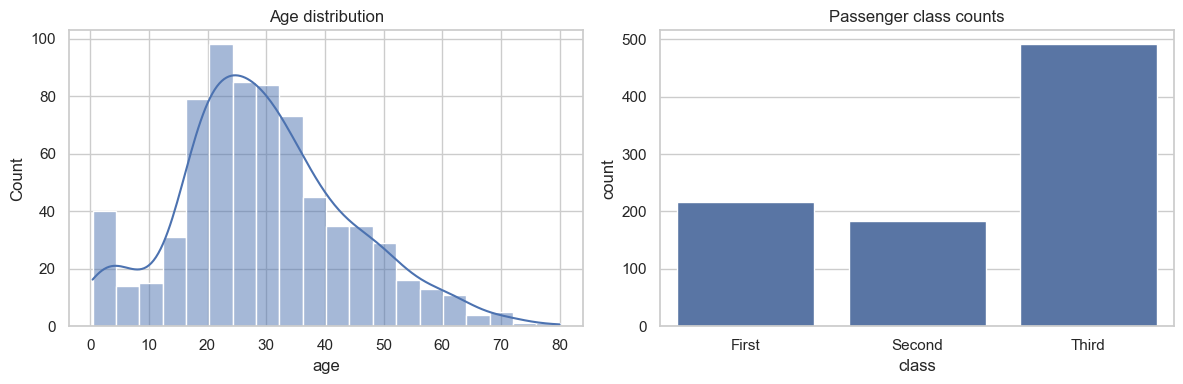

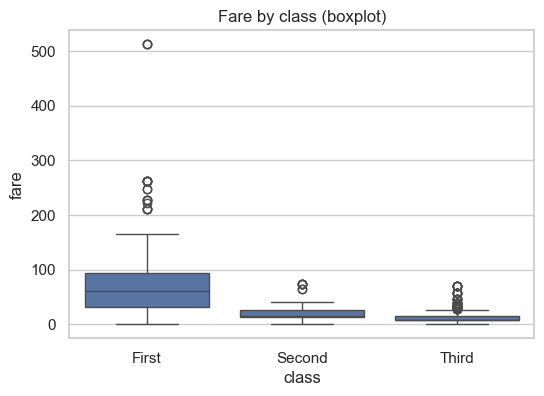

In [4]:
# Visualizations: numeric distributions and categorical counts
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['age'].dropna(), kde=True)
plt.title('Age distribution')

plt.subplot(1,2,2)
sns.countplot(data=df, x='class')
plt.title('Passenger class counts')
plt.tight_layout()
plt.show()

# Boxplot for fare to inspect potential outliers
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='class', y='fare')
plt.title('Fare by class (boxplot)')
plt.show()

## 2) Correlation & Covariance

- Compute correlation matrix for numeric features
- Visualize with heatmap


Correlation matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000



Covariance matrix:


,survived,pclass,age,sibsp,parch,fare
survived,0.236772,-0.137703,-0.551296,-0.018954,0.032017,6.221787
pclass,-0.137703,0.699015,-4.496004,0.076599,0.012429,-22.830196
age,-0.551296,-4.496004,211.019125,-4.163334,-2.344191,73.849030
sibsp,-0.018954,0.076599,-4.163334,1.216043,0.368739,8.748734
parch,0.032017,0.012429,-2.344191,0.368739,0.649728,8.661052
fare,6.221787,-22.830196,73.849030,8.748734,8.661052,2469.436846


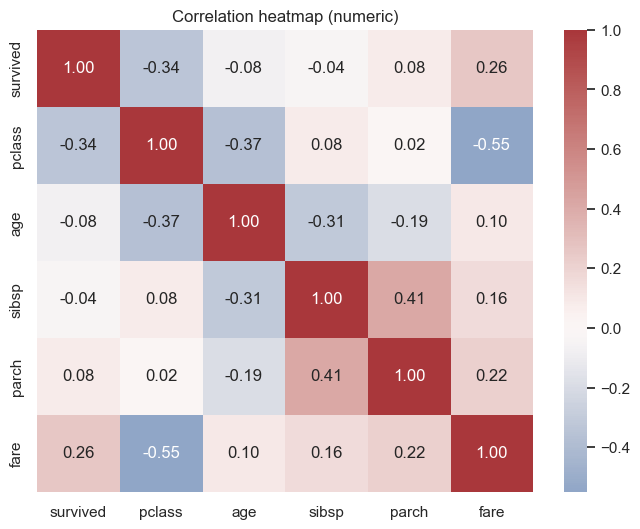

In [5]:
# Numeric columns
num = df.select_dtypes(include=[np.number])
corr = num.corr()
cov = num.cov()

print('Correlation matrix:')
display(corr)
print('\nCovariance matrix:')
display(cov)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlation heatmap (numeric)')
plt.show()

## 3) Data Cleaning — Managing Missing Data

Strategies demonstrated:
- Drop rows with missing target values
- Mean/median/mode imputation
- KNN imputation (numeric)
- Iterative Imputer (MICE-like) — numeric (with simple encodings for small categorical vars)

Notes: We limit ourselves to allowed libraries only.


In [6]:
# Show columns with missing values
display(df.isnull().sum().sort_values(ascending=False))

# 1) Drop rows where 'survived' is missing
df_drop_target = df.dropna(subset=['survived']).copy()
print('After dropping missing target, shape:', df_drop_target.shape)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

After dropping missing target, shape: (891, 15)


In [7]:
# 2) Simple imputation: mean for age, median for fare, mode for embarked
df_simple = df.copy()
df_simple['age_mean_impute'] = df_simple['age'].fillna(df_simple['age'].mean())
df_simple['fare_median_impute'] = df_simple['fare'].fillna(df_simple['fare'].median())
df_simple['embarked_mode_impute'] = df_simple['embarked'].fillna(df_simple['embarked'].mode()[0])

df_simple[['age','age_mean_impute','fare','fare_median_impute','embarked','embarked_mode_impute']].head()

,age,age_mean_impute,fare,fare_median_impute,embarked,embarked_mode_impute
0,22.0,22.0,7.2500,7.2500,S,S
1,38.0,38.0,71.2833,71.2833,C,C
2,26.0,26.0,7.9250,7.9250,S,S
3,35.0,35.0,53.1000,53.1000,S,S
4,35.0,35.0,8.0500,8.0500,S,S


In [8]:
# 3) KNN Imputer (numeric columns only)
knn_df = df.copy()
numeric_cols = knn_df.select_dtypes(include=[np.number]).columns.tolist()
# KNNImputer expects array input; will only impute numeric columns
knn_imputer = KNNImputer(n_neighbors=5)
knn_df[numeric_cols] = knn_imputer.fit_transform(knn_df[numeric_cols])
print('After KNN imputation, nulls in numeric cols:')
knn_df[numeric_cols].isnull().sum()

After KNN imputation, nulls in numeric cols:


survived    0
pclass      0
age         0
sibsp       0
parch       0
fare        0
dtype: int64

In [24]:
# 4) MICE Imputation
mice_df = df.copy()

# Simple encoding for 'sex' and 'embarked' so IterativeImputer can use them
mice_df['sex_enc'] = mice_df['sex'].map({'male':0,'female':1})
mice_df['embarked_enc'] = mice_df['embarked'].map({'S':0,'C':1,'Q':2})

imp = IterativeImputer(max_iter=10)
cols_for_imp = ['age','fare','sibsp','parch','sex_enc','embarked_enc']
mice_df[cols_for_imp] = imp.fit_transform(mice_df[cols_for_imp])

mice_df[cols_for_imp].isnull().sum()

age             0
fare            0
sibsp           0
parch           0
sex_enc         0
embarked_enc    0
dtype: int64

## 4) Data Cleaning — Handling Outliers

Methods:
- Z-score (univariate)
- IQR method (univariate)
- Capping (winsorizing) to limit extreme values

We'll apply these to `age` and `fare` as examples.


In [10]:
# Z-score method for 'age' (univariate)
age = df['age']
age_mean = age.mean(skipna=True)
age_std = age.std(skipna=True)
z_scores = (age - age_mean) / age_std
z_outliers = df[(z_scores.abs() > 3)][['age']]
print('Z-score outliers (age) count:', z_outliers.shape[0])
z_outliers.head()

Z-score outliers (age) count: 2


,age
630,80.0
851,74.0


In [11]:
# IQR method for 'fare'
fare = df['fare'].dropna()
Q1 = fare.quantile(0.25)
Q3 = fare.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
iqr_outliers = df[(df['fare'] < lower) | (df['fare'] > upper)][['fare']]
print('IQR outliers (fare) count:', iqr_outliers.shape[0])
iqr_outliers.head()

IQR outliers (fare) count: 116


,fare
1,71.2833
27,263.0000
31,146.5208
34,82.1708
52,76.7292


In [25]:
# Capping 
df_capped = df.copy()
df_capped['fare_capped'] = df_capped['fare'].clip(lower=lower, upper=upper)
df_capped[['fare','fare_capped']].describe().T

,count,mean,std,min,25%,50%,75%,max
fare,891.0,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
fare_capped,891.0,24.046813,20.481625,0.0,7.9104,14.4542,31.0,65.6344


## 6) Encoding Categorical Variables (simple, pandas-only)

- One-hot encode `embarked` and `class`
- Label-like mapping for `sex`


In [14]:
enc = fe.copy()
enc = pd.get_dummies(enc, columns=['embarked','class'], drop_first=True)
enc['sex_label'] = enc['sex'].map({'male':0,'female':1})

# Show a handful of new columns
[x for x in enc.columns if 'embarked_' in x or 'class_' in x][:10]

['embarked_Q', 'embarked_S', 'class_Second', 'class_Third']

## 7) Feature Selection

We will use:
- Variance threshold (remove near-constant numeric features)
- Correlation-based selection: pick numeric features with highest absolute correlation to `survived`

(No sklearn.feature_selection used — using pandas/numpy only.)


In [15]:
# Prepare numeric dataframe (after encoding); drop rows with missing target
fs = enc.copy().dropna(subset=['survived'])
y = fs['survived'].astype(int)
X_num = fs.select_dtypes(include=[np.number]).copy()

# 1) Variance threshold (manual): remove columns with very low variance
var_threshold = 1e-3
low_var_cols = X_num.columns[X_num.var() <= var_threshold].tolist()
print('Low variance columns (to drop):', low_var_cols)

X_var = X_num.drop(columns=low_var_cols)

# 2) Correlation with target: absolute correlation
corr_with_target = X_var.corrwith(y).abs().sort_values(ascending=False)
corr_with_target.head(15)

Low variance columns (to drop): []


survived       1.000000
sex_label      0.543351
pclass         0.338481
fare           0.257307
is_alone       0.203367
parch          0.081629
age            0.077221
sibsp          0.035322
family_size    0.016639
dtype: float64

In [16]:
# Choose top features by correlation (example: top 8 numeric features)
top_k = 8
top_features = corr_with_target.index[:top_k].tolist()
print('Top features by absolute correlation to target:', top_features)

Top features by absolute correlation to target: ['survived', 'sex_label', 'pclass', 'fare', 'is_alone', 'parch', 'age', 'sibsp']


## 8) Feature Scaling

Demonstrate MinMax, Standard, and Robust scaling on selected numeric features.


In [17]:
scale_df = X_var.copy()[top_features].fillna(0)
scalers = {
    'minmax': MinMaxScaler(),
    'standard': StandardScaler(),
    'robust': RobustScaler()
}
for name, scaler in scalers.items():
    scaled = scaler.fit_transform(scale_df)
    scaled_df = pd.DataFrame(scaled, columns=[f'{c}_{name}' for c in scale_df.columns], index=scale_df.index)
    display(scaled_df.head()) 

,survived_minmax,sex_label_minmax,pclass_minmax,fare_minmax,is_alone_minmax,parch_minmax,age_minmax,sibsp_minmax
0,0.0,0.0,1.0,0.014151,0.0,0.0,0.2750,0.125
1,1.0,1.0,0.0,0.139136,0.0,0.0,0.4750,0.125
2,1.0,1.0,1.0,0.015469,1.0,0.0,0.3250,0.000
3,1.0,1.0,0.0,0.103644,0.0,0.0,0.4375,0.125
4,0.0,0.0,1.0,0.015713,1.0,0.0,0.4375,0.000


,survived_standard,sex_label_standard,pclass_standard,fare_standard,is_alone_standard,parch_standard,age_standard,sibsp_standard
0,-0.789272,-0.737695,0.827377,-0.502445,-1.231645,-0.473674,-0.102313,0.432793
1,1.266990,1.355574,-1.566107,0.786845,-1.231645,-0.473674,0.807492,0.432793
2,1.266990,1.355574,0.827377,-0.488854,0.811922,-0.473674,0.125138,-0.474545
3,1.266990,1.355574,-1.566107,0.420730,-1.231645,-0.473674,0.636903,0.432793
4,-0.789272,-0.737695,0.827377,-0.486337,0.811922,-0.473674,0.636903,-0.474545


,survived_robust,sex_label_robust,pclass_robust,fare_robust,is_alone_robust,parch_robust,age_robust,sibsp_robust
0,0.0,0.0,0.0,-0.312011,-1.0,0.0,-0.068966,1.0
1,1.0,1.0,-2.0,2.461242,-1.0,0.0,0.482759,1.0
2,1.0,1.0,0.0,-0.282777,0.0,0.0,0.068966,0.0
3,1.0,1.0,-2.0,1.673732,-1.0,0.0,0.379310,1.0
4,0.0,0.0,0.0,-0.277363,0.0,0.0,0.379310,0.0


## 9) Final EDA: Visualizations & Insights

- Visualize survival rates by engineered features
- Plot correlations among top features


C:\Users\USER\AppData\Local\Temp\ipykernel_23736\792751660.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=fs, x='is_alone', y='survived', ci=None)
C:\Users\USER\AppData\Local\Temp\ipykernel_23736\792751660.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=fs, x='class', y='survived', ci=None)


ValueError: Could not interpret value `class` for `x`. An entry with this name does not appear in `data`.

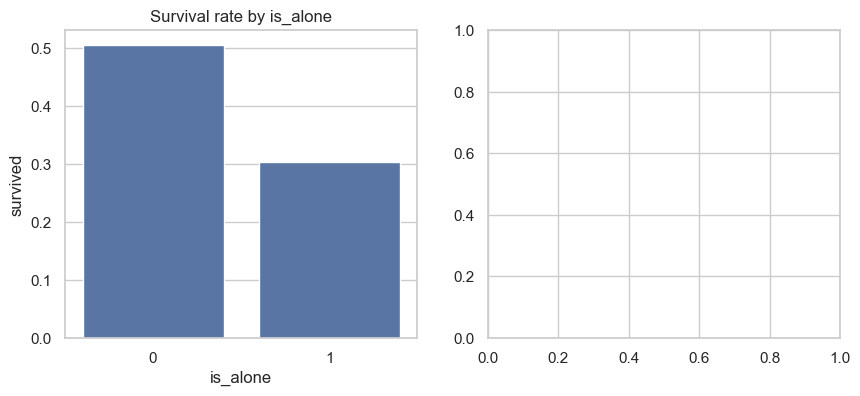

In [18]:
# Survival rates by is_alone and class
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.barplot(data=fs, x='is_alone', y='survived', ci=None)
plt.title('Survival rate by is_alone')

plt.subplot(1,2,2)
if 'class' in df.columns:
    sns.barplot(data=fs, x='class', y='survived', ci=None)
    plt.title('Survival rate by class')
plt.tight_layout()
plt.show()

# Pairplot for top numeric features (if numeric count small)
plot_cols = [c for c in top_features if c in fs.columns][:6]
if len(plot_cols) > 1:
    sns.pairplot(fs[plot_cols + ['survived']].dropna(), hue='survived', corner=True)
    plt.suptitle('Pairplot of top features vs survived', y=1.02)
    plt.show()

# Correlation heatmap of top features
plt.figure(figsize=(8,6))
sns.heatmap(fs[top_features].corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlation among top selected numeric features')
plt.show()